# py-MARVEL plate-based RNA-seq tutorial

This notebook rewrites the main plate-based MARVEL tutorial from `plate_ref.txt` using the `marvel_py` API. The example data are the Smart-seq2 iPSC / endoderm tutorial files distributed with this repository under `external_plate_data/unpacked/Data`.

The workflow follows the same practical order as the R tutorial:

1. inspect input files;
2. create a `MarvelPlate` object;
3. compute PSI for plate splicing events;
4. subset passing iPSC and endoderm cells;
5. run pre-flight alignment checks;
6. summarize expressed events;
7. run differential gene and splicing analysis;
8. label DE results and save reusable outputs.

Notes:

- The bundled flat external data include rMATS features for `SE`, `MXE`, `RI`, `A5SS`, and `A3SS`.
- `plate_ref.txt` also detects `AFE` and `ALE` from GTF. Those steps are included below as an optional switch because they are slower and the downloaded flat feature directories do not include precomputed AFE/ALE tables.
- Plot helpers in `marvel_py` store labeled tables and summaries; this notebook uses lightweight pandas/matplotlib plots for tutorial readability.

## 1. Setup

Run this notebook in the `ove` micromamba environment, where `marvel_py` is importable as a normal package. The bundled input and output directories are declared explicitly below.

In [1]:
from pathlib import Path

import marvel_py as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('/data20T/dev/omicverse-eco/py-MARVEL')
DATA_ROOT = PROJECT_ROOT / 'external_plate_data' / 'unpacked' / 'Data'
OUTPUT_DIR = PROJECT_ROOT / 'examples' / 'output' / 'plate_data'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('project root:', PROJECT_ROOT)
print('data root:', DATA_ROOT)
print('output dir:', OUTPUT_DIR)

project root: /data20T/dev/omicverse-eco/py-MARVEL
data root: /data20T/dev/omicverse-eco/py-MARVEL/external_plate_data/unpacked/Data
output dir: /data20T/dev/omicverse-eco/py-MARVEL/examples/output/plate_data


In [2]:
mp.__file__

'/data20T/dev/omicverse-eco/py-MARVEL/marvel_py/__init__.py'

## 2. Input files

`plate_ref.txt` reads six input classes: sample metadata, splice junction counts, rMATS splicing features, intron counts for RI, gene expression, gene metadata, and GTF. Here we keep paths explicit so the notebook doubles as a checklist for user data.

### Download the tutorial data

The processed input files used by the original MARVEL plate tutorial are available from:

- Main tutorial archive: <http://datashare.molbiol.ox.ac.uk/public/project/meadlab/wwen/MARVEL/Tutorial/Plate/Data.zip>

Download and unpack it before running this notebook:

```bash
cd /data20T/dev/omicverse-eco/py-MARVEL
mkdir -p external_plate_data/unpacked
wget -O external_plate_data/Data.zip \
  http://datashare.molbiol.ox.ac.uk/public/project/meadlab/wwen/MARVEL/Tutorial/Plate/Data.zip
unzip -o external_plate_data/Data.zip -d external_plate_data/unpacked
```

The original HTML tutorial also links optional preprocessing examples for splicing nomenclature and RI intron-count preparation:

- Splicing nomenclature notes: <https://wenweixiong.github.io/Splicing_Nomenclature>
- Splicing nomenclature example data/code: <https://drive.google.com/file/d/1SIR1-GLXU8Qp0Wh4PkoABliPmW91peu2/view?usp=sharing>
- RI intron-count preparation example data/code: <https://drive.google.com/file/d/1pZREqT79OXbsyDnFXQWX_XRZpxl_bNfM/view?usp=sharing>


In [3]:
paths = {
    'splice_pheno': DATA_ROOT / 'SJ' / 'SJ_phenoData.txt',
    'splice_junction': DATA_ROOT / 'SJ' / 'SJ.txt',
    'intron_counts': DATA_ROOT / 'MARVEL' / 'PSI' / 'RI' / 'Counts_by_Region.txt',
    'gene_feature': DATA_ROOT / 'RSEM' / 'TPM_featureData.txt',
    'exp': DATA_ROOT / 'RSEM' / 'TPM.txt',
    'gtf': DATA_ROOT / 'GTF' / 'gencode.v31.annotation.gtf',
}

splice_feature = {
    'SE': DATA_ROOT / 'rMATS' / 'SE' / 'SE_featureData.txt',
    'MXE': DATA_ROOT / 'rMATS' / 'MXE' / 'MXE_featureData.txt',
    'RI': DATA_ROOT / 'rMATS' / 'RI' / 'RI_featureData.txt',
    'A5SS': DATA_ROOT / 'rMATS' / 'A5SS' / 'A5SS_featureData.txt',
    'A3SS': DATA_ROOT / 'rMATS' / 'A3SS' / 'A3SS_featureData.txt',
    # Optional terminal exon event types can be detected from GTF below.
    'AFE': None,
    'ALE': None,
}

missing = [str(path) for path in list(paths.values()) + [p for p in splice_feature.values() if p is not None] if not Path(path).exists()]
if missing:
    raise FileNotFoundError('\n'.join(missing))

pd.DataFrame(
    [{'name': key, 'path': str(value), 'exists': Path(value).exists()} for key, value in paths.items()]
    + [{'name': f'feature_{key}', 'path': str(value), 'exists': value is not None and Path(value).exists()} for key, value in splice_feature.items()]
)

               name                                               path  exists
0      splice_pheno  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
1   splice_junction  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
2     intron_counts  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
3      gene_feature  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
4               exp  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
5               gtf  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
6        feature_SE  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
7       feature_MXE  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
8        feature_RI  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
9      feature_A5SS  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
10     feature_A3SS  /data20T/dev/omicverse-eco/py-MARVEL/external_...    True
11      feature_AFE                                 

In [4]:
splice_pheno_preview = pd.read_csv(paths['splice_pheno'], sep='\t')
splice_junction_preview = pd.read_csv(paths['splice_junction'], sep='\t', nrows=5)
gene_feature_preview = pd.read_csv(paths['gene_feature'], sep='\t', nrows=5)
exp_preview = pd.read_csv(paths['exp'], sep='\t', nrows=5)

print('Sample metadata')
display(splice_pheno_preview.head())
print('\ncell.type counts')
display(splice_pheno_preview['cell.type'].value_counts(dropna=False).rename_axis('cell.type').reset_index(name='n'))
print('\nqc.seq counts')
display(splice_pheno_preview['qc.seq'].value_counts(dropna=False).rename_axis('qc.seq').reset_index(name='n'))
print('\nSplice junction counts preview')
display(splice_junction_preview)
print('\nGene metadata preview')
display(gene_feature_preview)
print('\nExpression matrix preview')
display(exp_preview)

Sample metadata


    sample.id cell.type  sample.type qc.seq
0  ERR1562083   Unknown  Single Cell   pass
1  ERR1562084      iPSC  Single Cell   pass
2  ERR1562085      iPSC  Single Cell   pass
3  ERR1562086      iPSC  Single Cell   pass
4  ERR1562087      iPSC  Single Cell   pass


cell.type counts


  cell.type   n
0      iPSC  84
1  Endoderm  57
2   Unknown  51


qc.seq counts


...

               coord.intron  ERR1562083  ERR1562084  ERR1562085  ERR1562086  \
0  chr1:100001423:100018395         NaN         NaN         NaN         NaN   
1  chr1:100002838:100003170         NaN         NaN         NaN         NaN   
2  chr1:100002846:100042840         NaN         NaN         NaN         NaN   
3  chr1:100004331:100010660         NaN         NaN         NaN         NaN   
4  chr1:100004393:100025082         NaN         NaN         NaN         NaN   

   ERR1562087  ERR1562088  ERR1562089  ERR1562090  ERR1562091  ...  \
0         NaN         NaN         NaN         NaN         NaN  ...   
1         NaN         NaN         NaN         NaN         NaN  ...   
2         NaN         NaN         NaN         NaN         NaN  ...   
3         NaN         NaN         NaN         NaN         NaN  ...   
4         NaN         NaN         NaN         NaN         NaN  ...   

   ERR1562265  ERR1562266  ERR1562267  ERR1562268  ERR1562269  ERR1562270  \
0         NaN         NaN  


Gene metadata preview


              gene_id gene_short_name       gene_type
0  ENSG00000000003.14          TSPAN6  protein_coding
1   ENSG00000000005.6            TNMD  protein_coding
2  ENSG00000000419.12            DPM1  protein_coding
3  ENSG00000000457.14           SCYL3  protein_coding
4  ENSG00000000460.17        C1orf112  protein_coding


Expression matrix preview


              gene_id  ERR1562083  ERR1562084  ERR1562085  ERR1562086  \
0  ENSG00000000003.14      343.26      163.45      210.43      190.46   
1   ENSG00000000005.6        5.69        0.00        0.00        0.00   
2  ENSG00000000419.12      288.02      155.26       42.49      238.67   
3  ENSG00000000457.14        1.58        8.71        0.00        1.06   
4  ENSG00000000460.17       41.23       28.53      100.17       66.43   

   ERR1562087  ERR1562088  ERR1562089  ERR1562090  ERR1562091  ...  \
0      262.68      163.35        0.00      238.73      127.53  ...   
1        0.00        0.00        0.00       22.36      148.26  ...   
2      169.88       75.70        2.66      270.37      187.31  ...   
3        0.00        0.00        0.00        0.81        0.00  ...   
4        2.56        0.00        0.00       23.10        0.54  ...   

   ERR1562265  ERR1562266  ERR1562267  ERR1562268  ERR1562269  ERR1562270  \
0           0        2.39      222.07           0      164.23  

## 3. Create a `MarvelPlate` object

This is the Python equivalent of `CreateMarvelObject(...)` in the R tutorial.

In [5]:
plate = mp.create_marvel_object(
    splice_pheno=paths['splice_pheno'],
    splice_junction=paths['splice_junction'],
    splice_feature=splice_feature,
    intron_counts=paths['intron_counts'],
    gene_feature=paths['gene_feature'],
    exp=paths['exp'],
    gtf=paths['gtf'],
)

print('samples:', len(plate.splice_pheno))
print('splice junctions:', len(plate.splice_junction))
print('genes:', len(plate.gene_feature))
print('feature rows:', {event: len(df) for event, df in plate.splice_feature.items() if df is not None and not df.empty})

samples: 192
splice junctions: 1092380
genes: 60603
feature rows: {'SE': 51154, 'MXE': 4892, 'RI': 11829, 'A5SS': 10464, 'A3SS': 13160}


## 4. Optional AFE/ALE detection

The R tutorial detects alternative first and last exon events from the GTF. The bundled external flat data do not include precomputed AFE/ALE feature tables, so this notebook leaves terminal exon detection off by default. Set `RUN_TERMINAL_EVENT_DETECTION = True` to include AFE/ALE in the PSI and event count sections.

In [6]:
RUN_TERMINAL_EVENT_DETECTION = False

if RUN_TERMINAL_EVENT_DETECTION:
    for event_type in ['AFE', 'ALE']:
        plate = mp.detect_events(
            plate,
            event_type=event_type,
            min_cells=50,
            min_expr=1,
            track_progress=False,
        )
    print('detected terminal event rows:', {event: len(plate.splice_feature[event]) for event in ['AFE', 'ALE']})
else:
    print('Skipping AFE/ALE detection. Set RUN_TERMINAL_EVENT_DETECTION=True to run it.')

Skipping AFE/ALE detection. Set RUN_TERMINAL_EVENT_DETECTION=True to run it.


## 5. Check splice junction alignment and compute PSI

This mirrors `CheckAlignment(..., level="SJ")` followed by repeated `ComputePSI(...)` calls. The tutorial uses a coverage threshold of 10 and an uneven coverage multiplier of 10 for SE/MXE. `read_length=1` matches the bundled RI intron coverage matrix.

In [7]:
plate = mp.check_alignment(plate, level='SJ')

compute_psi_events = ['SE', 'MXE', 'RI', 'A5SS', 'A3SS']
if RUN_TERMINAL_EVENT_DETECTION:
    compute_psi_events += ['AFE', 'ALE']

for event_type in compute_psi_events:
    plate = mp.compute_psi(
        plate,
        event_type=event_type,
        coverage_threshold=10,
        uneven_coverage_multiplier=10,
        read_length=1,
    )

psi_summary = pd.DataFrame(
    {
        'event_type': event_type,
        'validated_features': len(plate.splice_feature_validated[event_type]),
        'psi_rows': len(plate.psi[event_type]),
        'psi_cells': max(0, plate.psi[event_type].shape[1] - 1),
    }
    for event_type in compute_psi_events
)
psi_summary

  event_type  validated_features  psi_rows  psi_cells
0         SE               20509     20509        192
1        MXE                1279      1279        192
2         RI                8295      8295        192
3       A5SS                5163      5163        192
4       A3SS                5852      5852        192

## 6. Subset cells and run pre-flight checks

Following `plate_ref.txt`, keep iPSC and Endoderm cells that passed sequencing QC. Then log2-transform expression values and check splicing/gene alignment.

In [8]:
pheno = plate.splice_pheno.copy()
keep_mask = pheno['cell.type'].isin(['iPSC', 'Endoderm']) & (pheno['qc.seq'] == 'pass')
sample_ids = pheno.loc[keep_mask, 'sample.id'].astype(str).tolist()

print('selected samples:', len(sample_ids))
print(pheno.loc[keep_mask, 'cell.type'].value_counts())

plate = mp.subset_samples(plate, sample_ids=sample_ids)
plate = mp.transform_exp_values(plate, offset=1, transformation='log2', threshold_lower=1)
plate = mp.check_alignment(plate, level='splicing')
plate = mp.check_alignment(plate, level='gene')
plate = mp.check_alignment(plate, level='splicing and gene')

plate.splice_pheno.head()

selected samples: 136
cell.type
iPSC        83
Endoderm    53
Name: count, dtype: int64


    sample.id cell.type  sample.type qc.seq
1  ERR1562084      iPSC  Single Cell   pass
2  ERR1562085      iPSC  Single Cell   pass
3  ERR1562086      iPSC  Single Cell   pass
4  ERR1562087      iPSC  Single Cell   pass
5  ERR1562088      iPSC  Single Cell   pass

## 7. Count expressed splicing events

This reproduces the iPSC and Endoderm event count tables from the R tutorial for the event types computed above. If AFE/ALE detection is off, percentages are relative to the five rMATS event classes only.

In [9]:
cell_group_g1 = plate.get_sample_ids('cell.type', ['iPSC'])
cell_group_g2 = plate.get_sample_ids('cell.type', ['Endoderm'])
cell_groups = {'iPSC': cell_group_g1, 'Endoderm': cell_group_g2}

count_tables = {}
for group_name, group_samples in cell_groups.items():
    table = plate.count_events(sample_ids=group_samples, min_cells=25, label=f'{group_name}_min_cells_25')
    count_tables[group_name] = table.sort_values('freq', ascending=False).reset_index(drop=True)
    print(group_name)
    display(count_tables[group_name])

iPSC


  event_type  freq        pct
0         SE  5270  49.660761
1         RI  2030  19.129288
2       A3SS  1746  16.453072
3       A5SS  1494  14.078402
4        MXE    72   0.678477

Endoderm


  event_type  freq        pct
0         SE  1966  46.687248
1         RI   943  22.393731
2       A3SS   656  15.578247
3       A5SS   625  14.842080
4        MXE    21   0.498694

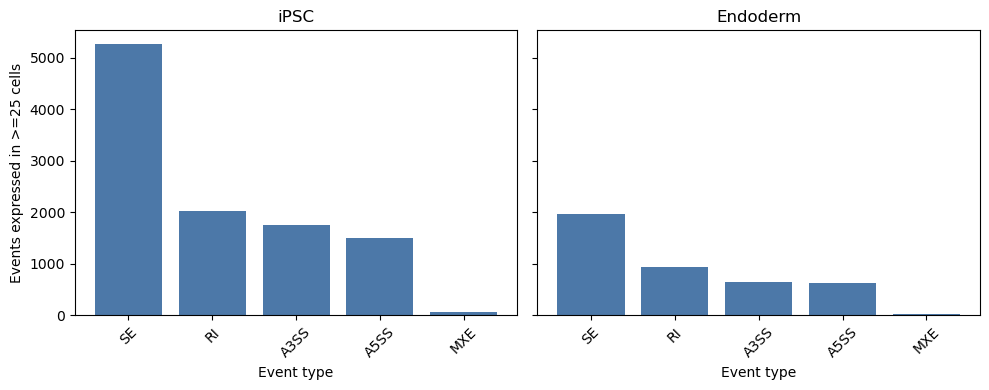

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (group_name, table) in zip(axes, count_tables.items()):
    ax.bar(table['event_type'], table['freq'], color='#4C78A8')
    ax.set_title(group_name)
    ax.set_xlabel('Event type')
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Events expressed in >=25 cells')
fig.tight_layout()
plt.show()

## 8. Modality analysis

`AssignModality` classifies PSI distributions into included/excluded/bimodal/middle/multimodal classes. Here we run it for iPSC first, then summarize the modality proportions.

In [11]:
plate = mp.assign_modality(plate, sample_ids=cell_group_g1, min_cells=25, seed=1)
modality_cols = ['tran_id', 'event_type', 'gene_id', 'gene_short_name', 'modality.bimodal.adj']
display(plate.modality_results[modality_cols].head())

plate = mp.prop_modality(
    plate,
    modality_column='modality.bimodal.adj',
    modality_type='extended',
    event_type=compute_psi_events,
    across_event_type=False,
)
modality_summary = plate.modality_prop.sort_values('freq', ascending=False).reset_index(drop=True)
modality_summary

                                             tran_id event_type  \
0  chrX:155090784:155090839:+@chrX:155099315:1550...         SE   
1  chrX:155090784:155090839:+@chrX:155116057:1551...         SE   
2  chrX:155033403:155033553:+@chrX:155046509:1550...         SE   
3  chrX:155046509:155046584:+@chrX:155047369:1550...         SE   
4  chrX:154399338:154399396:+@chrX:154399487:1543...         SE   

              gene_id gene_short_name modality.bimodal.adj  
0  ENSG00000185515.14           BRCC3   Excluded.Dispersed  
1  ENSG00000185515.14           BRCC3     Included.Primary  
2  ENSG00000165775.18          FUNDC2   Included.Dispersed  
3  ENSG00000165775.18          FUNDC2     Excluded.Primary  
4  ENSG00000147403.16           RPL10     Included.Primary  

             modality  freq        pct
0  Included.Dispersed  2993  28.203920
1  Excluded.Dispersed  2932  27.629099
2    Excluded.Primary  2352  22.163588
3    Included.Primary  1976  18.620430
4          Multimodal   215   2.026008
5              Middle    85   0.800980
6             Bimodal    59   0.555974

## 9. Differential gene expression

This is the Python equivalent of `CompareValues(..., level="gene", method="wilcox")` for iPSC versus Endoderm. Group 1 is iPSC, so positive `log2fc` means higher expression in Endoderm relative to iPSC in this implementation, matching the stored mean difference (`mean.g2 - mean.g1`).

In [12]:
plate = mp.compare_values(
    plate,
    cell_group_g1=cell_group_g1,
    cell_group_g2=cell_group_g2,
    min_cells=3,
    method='wilcox',
    method_adjust='fdr',
    level='gene',
    show_progress=False,
)

de_gene = plate.de_gene.sort_values('p.val.adj').reset_index(drop=True)
de_gene.head(10)

              gene_id gene_short_name       gene_type  n.cells.g1  n.cells.g2  \
0  ENSG00000141448.10           GATA6  protein_coding           0          52   
1   ENSG00000273706.4            LHX1  protein_coding           1          52   
2   ENSG00000250361.8            GYPB  protein_coding           3          52   
3   ENSG00000266010.2       GATA6-AS1          lncRNA           1          51   
4  ENSG00000185155.11           MIXL1  protein_coding           2          51   
5  ENSG00000158815.11           FGF17  protein_coding           0          50   
6   ENSG00000147869.4            CER1  protein_coding           8          53   
7  ENSG00000183569.18          SERHL2  protein_coding           8          53   
8  ENSG00000163508.12           EOMES  protein_coding           2          50   
9   ENSG00000286467.1      AC108052.1          lncRNA           2          50   

    mean.g1    mean.g2     log2fc  statistic         p.val     p.val.adj  
0  0.000000   6.051803   6.051803

    sig   freq
0  n.s.  12812
1  down   6864
2    up   1383

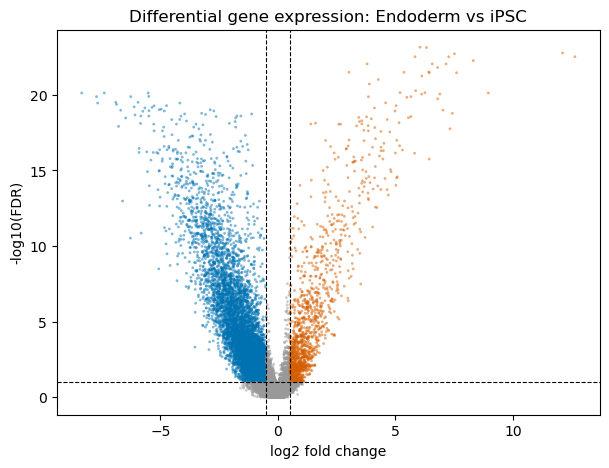

In [13]:
plate = mp.plot_de_values(
    plate,
    pval=0.10,
    log2fc=0.5,
    level='gene.global',
    anno=False,
)

gene_de_labeled = plate.de_plots['gene.global']['table']
gene_de_summary = plate.de_plots['gene.global']['summary']
display(gene_de_summary)

plot_df = gene_de_labeled.copy()
plot_df['minus_log10_fdr'] = -np.log10(plot_df['p.val.adj'].clip(lower=np.finfo(float).tiny))
colors = plot_df['sig'].map({'up': '#D55E00', 'down': '#0072B2', 'n.s.': '#999999'}).fillna('#999999')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df['log2fc'], plot_df['minus_log10_fdr'], s=4, c=colors, alpha=0.5, linewidths=0)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
ax.axvline(-0.5, color='black', linestyle='--', linewidth=0.8)
ax.axhline(-np.log10(0.10), color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('log2 fold change')
ax.set_ylabel('-log10(FDR)')
ax.set_title('Differential gene expression: Endoderm vs iPSC')
plt.show()

## 10. Differential splicing

MARVEL compares the PSI distribution between cell populations. The R tutorial recommends Anderson-Darling (`ad`) and DTS (`dts`). `ad` is faster and is used here by default for a practical notebook run; uncomment `dts` if you want the additional method.

In [14]:
splicing_methods = ['ad']
# splicing_methods = ['ad', 'dts']  # DTS is slower because it uses bootstrap sampling.

for method in splicing_methods:
    plate = mp.compare_values(
        plate,
        cell_group_g1=cell_group_g1,
        cell_group_g2=cell_group_g2,
        min_cells=25,
        method=method,
        method_adjust='fdr',
        level='splicing',
        event_type=compute_psi_events,
        show_progress=False,
    )

for method in splicing_methods:
    print(method)
    display(plate.de_splicing[method].sort_values('p.val.adj').head())

ad


                                                tran_id event_type  \
2073  chr13:43059394:43059714:+@chr13:43062190:43062295         RI   
293   chr15:24962114:24962209:+@chr15:24967029:24967...         SE   
3146  chr17:8383254:8382781|8383157:-@chr17:8382143:...       A5SS   
521   chr10:78037194:78037304:+@chr10:78037439:78037...         SE   
3533  chr10:78037194:78037304:+@chr10:78037439|78040...       A3SS   

                 gene_id gene_short_name       gene_type  n.cells.g1  \
2073   ENSG00000120675.6         DNAJC15  protein_coding          67   
293   ENSG00000128739.22           SNRPN  protein_coding          83   
3146  ENSG00000161970.15           RPL26  protein_coding          83   
521   ENSG00000138326.20           RPS24  protein_coding          82   
3533  ENSG00000138326.20           RPS24  protein_coding          83   

      n.cells.g2    mean.g1    mean.g2  mean.diff  statistic         p.val  \
2073          53   0.014075  12.201045  12.186970  66.959266  6.3200

    sig  freq
0  n.s.  3227
1  down   498
2    up   278

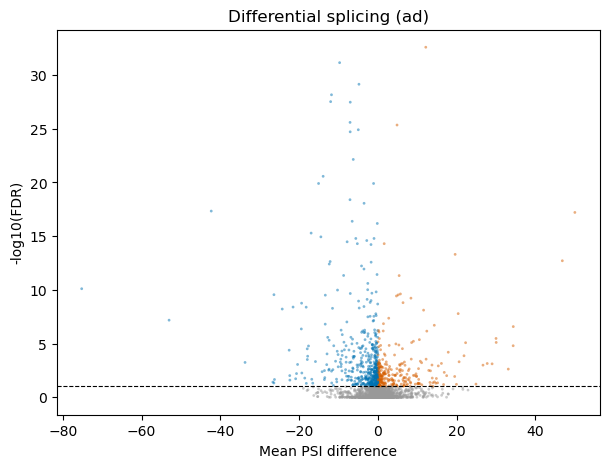

In [15]:
method = splicing_methods[0]
plate = mp.plot_de_values(
    plate,
    method=method,
    pval=0.10,
    delta=0,
    level='splicing',
    anno=False,
)

splicing_de_labeled = plate.de_plots['splicing_methods'][method]['table']
splicing_de_summary = plate.de_plots['splicing_methods'][method]['summary']
display(splicing_de_summary)

plot_df = splicing_de_labeled.copy()
plot_df['minus_log10_fdr'] = -np.log10(plot_df['p.val.adj'].clip(lower=np.finfo(float).tiny))
colors = plot_df['sig'].map({'up': '#D55E00', 'down': '#0072B2', 'n.s.': '#999999'}).fillna('#999999')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df['mean.diff'], plot_df['minus_log10_fdr'], s=4, c=colors, alpha=0.5, linewidths=0)
ax.axhline(-np.log10(0.10), color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Mean PSI difference')
ax.set_ylabel('-log10(FDR)')
ax.set_title(f'Differential splicing ({method})')
plt.show()

## 11. Differential expression among differentially spliced genes

This mirrors the `level="gene.spliced"` section in `plate_ref.txt`. The object method `compare_values_spliced_genes` first selects genes linked to significant splicing events and then runs gene-level DE on that subset.

In [16]:
plate.compare_values_spliced_genes(
    cell_group_g1=cell_group_g1,
    cell_group_g2=cell_group_g2,
    psi_method=splicing_methods,
    psi_pval=[0.10] * len(splicing_methods),
    psi_delta=0,
    method_de_gene='wilcox',
    method_adjust_de_gene='fdr',
)

de_spliced_gene = plate.de_spliced_gene.sort_values('p.val.adj').reset_index(drop=True)
de_spliced_gene.head(10)

              gene_id gene_short_name       gene_type  n.cells.g1  n.cells.g2  \
0  ENSG00000147601.14           TERF1  protein_coding          83          51   
1  ENSG00000154277.12           UCHL1  protein_coding          83          43   
2  ENSG00000121570.12           DPPA4  protein_coding          83          53   
3   ENSG00000119705.9           SLIRP  protein_coding          83          53   
4  ENSG00000026025.16             VIM  protein_coding          59          53   
5  ENSG00000163931.16             TKT  protein_coding          83          53   
6  ENSG00000110492.15             MDK  protein_coding          83          53   
7  ENSG00000104341.16         LAPTM4B  protein_coding          83          53   
8   ENSG00000239672.7            NME1  protein_coding          83          48   
9  ENSG00000181163.13            NPM1  protein_coding          83          53   

     mean.g1    mean.g2    log2fc  statistic         p.val     p.val.adj  
0  10.909400   5.946858 -4.962541

## 12. PCA using DE genes and splicing events

`marvel_py.run_pca` supports both `level='gene'` and `level='splicing'`. The gene-level PCA uses expression values; the splicing-level PCA uses PSI values with missing-value imputation.

In [17]:
de_gene_features = (
    plate.de_gene.sort_values('p.val.adj')['gene_id'].dropna().astype(str).head(200).tolist()
    if plate.de_gene is not None and not plate.de_gene.empty
    else []
)
if not de_gene_features:
    de_gene_features = plate.gene_feature['gene_id'].dropna().astype(str).head(200).tolist()

plate = mp.run_pca(
    plate,
    cell_group_column='cell.type',
    features=de_gene_features,
    min_cells=25,
    level='gene',
)


In [18]:
de_splicing_features = []
if plate.de_splicing:
    for table in plate.de_splicing.values():
        if table is not None and not table.empty and 'tran_id' in table.columns:
            de_splicing_features.extend(table['tran_id'].dropna().astype(str).head(200).tolist())
de_splicing_features = list(dict.fromkeys(de_splicing_features))
if not de_splicing_features:
    de_splicing_features = plate.psi['SE']['tran_id'].dropna().astype(str).head(200).tolist()

plate = mp.run_pca(
    plate,
    cell_group_column='cell.type',
    features=de_splicing_features,
    min_cells=25,
    level='splicing',
    method_impute='random',
)


## 13. Save tutorial outputs

`save_outputs` writes flat tables that can be compared with R MARVEL outputs or reused in later notebooks.

In [19]:
summary = {
    'n_samples': int(len(plate.splice_pheno)),
    'group1': {'name': 'iPSC', 'n': int(len(cell_group_g1))},
    'group2': {'name': 'Endoderm', 'n': int(len(cell_group_g2))},
    'psi_events_computed': compute_psi_events,
    'validated_events': {event: int(len(plate.splice_feature_validated[event])) for event in compute_psi_events},
    'de_gene_rows': int(len(plate.de_gene)),
    'de_splicing_rows': {method: int(len(plate.de_splicing[method])) for method in splicing_methods},
    'de_spliced_gene_rows': int(len(plate.de_spliced_gene)),
}

plate.save_outputs(OUTPUT_DIR, summary)
pd.Series(summary)

n_samples                                                             136
group1                                          {'name': 'iPSC', 'n': 83}
group2                                      {'name': 'Endoderm', 'n': 53}
psi_events_computed                             [SE, MXE, RI, A5SS, A3SS]
validated_events        {'SE': 20509, 'MXE': 1279, 'RI': 8295, 'A5SS':...
de_gene_rows                                                        21059
de_splicing_rows                                             {'ad': 4003}
de_spliced_gene_rows                                                  469
dtype: object

In [20]:
print('Output files:')
for path in sorted(OUTPUT_DIR.glob('*')):
    print(path.relative_to(PROJECT_ROOT))

Output files:
examples/output/plate_data/de_gene.tsv
examples/output/plate_data/de_spliced_gene.tsv
examples/output/plate_data/de_splicing_ad.tsv
examples/output/plate_data/exp.tsv
examples/output/plate_data/gene_feature.tsv
examples/output/plate_data/intron_counts.tsv
examples/output/plate_data/modality_results.tsv
examples/output/plate_data/n_events_min_cells_Endoderm_min_cells_25.tsv
examples/output/plate_data/n_events_min_cells_iPSC_min_cells_25.tsv
examples/output/plate_data/psi_a3ss.tsv
examples/output/plate_data/psi_a5ss.tsv
examples/output/plate_data/psi_feature_a3ss.tsv
examples/output/plate_data/psi_feature_a5ss.tsv
examples/output/plate_data/psi_feature_mxe.tsv
examples/output/plate_data/psi_feature_ri.tsv
examples/output/plate_data/psi_feature_se.tsv
examples/output/plate_data/psi_mxe.tsv
examples/output/plate_data/psi_ri.tsv
examples/output/plate_data/psi_se.tsv
examples/output/plate_data/splice_junction.tsv
examples/output/plate_data/splice_pheno.tsv
examples/output/plate

## 14. Where this differs from the R tutorial

This notebook intentionally focuses on the core plate workflow that is implemented and tested in `marvel_py`:

- AFE/ALE detection is optional because the bundled flat external data only provide rMATS feature files for `SE/MXE/RI/A5SS/A3SS`.
- DTS can be run by adding it to `splicing_methods`, but it is slower than `ad`.
- `marvel_py.run_pca` supports both gene-level and splicing-level PCA; splicing-level PCA uses PSI values and requires computed PSI tables for the selected events.
- Python plotting helpers mostly store labeled tables and summaries; this notebook uses pandas/matplotlib for display.